In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

In [3]:
import pandas as pd

news = pd.read_csv("../data/raw/newsData/raw_analyst_ratings.csv")
news.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [4]:
news.info()
news.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [5]:
news = news.dropna(subset=["headline"])
news["date"] = pd.to_datetime(news["date"], errors="coerce")
news["headline_length"] = news["headline"].astype(str).apply(len)

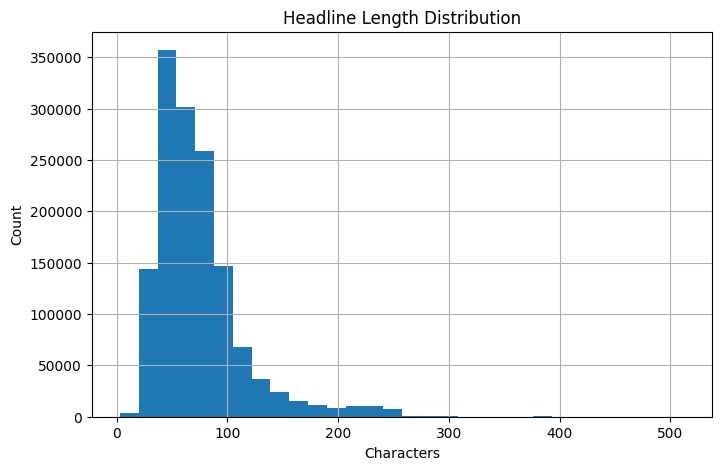

In [6]:
plt.figure(figsize=(8,5))
news["headline_length"].hist(bins=30)
plt.title("Headline Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

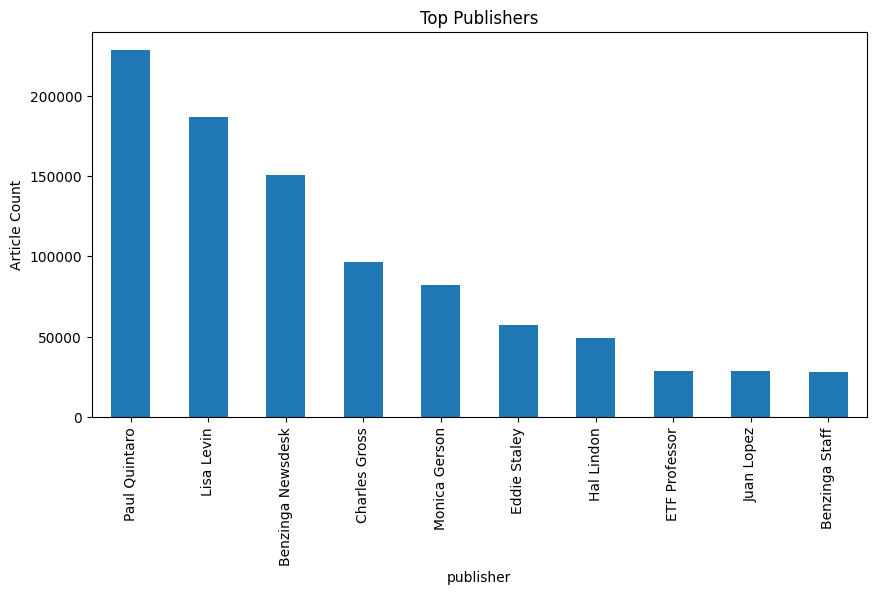

In [7]:
top_publishers = news["publisher"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_publishers.plot(kind="bar")
plt.title("Top Publishers")
plt.ylabel("Article Count")
plt.show()

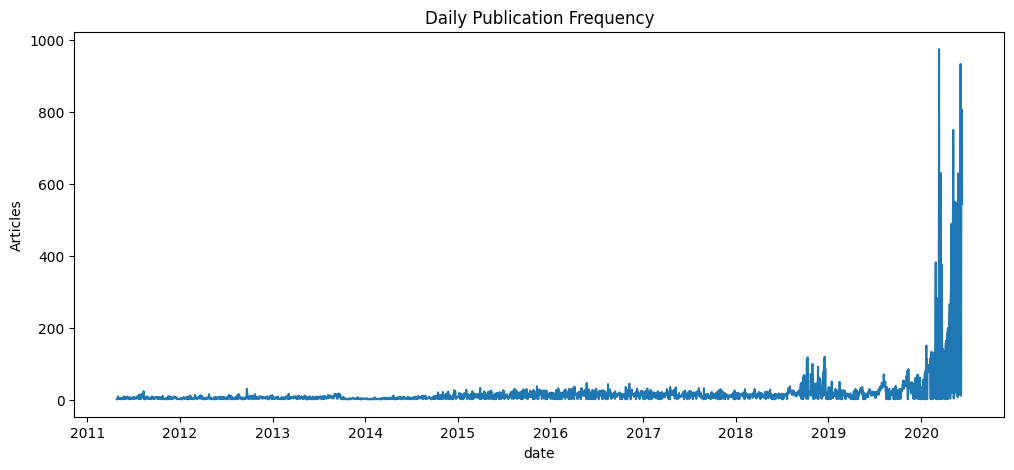

In [8]:
daily_counts = news.groupby(news["date"].dt.date).size()

plt.figure(figsize=(12,5))
daily_counts.plot()
plt.title("Daily Publication Frequency")
plt.ylabel("Articles")
plt.show()

In [9]:
vectorizer = CountVectorizer(stop_words="english", max_features=15)
X = vectorizer.fit_transform(news["headline"].astype(str))

words = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

keyword_df = pd.DataFrame({
    "word": words,
    "count": counts
}).sort_values("count", ascending=False)

keyword_df

,word,count
13,vs,162099
11,stocks,161776
4,est,140604
3,eps,128897
5,market,120558
10,shares,114313
8,reports,108710
12,update,91723
2,earnings,87399
9,sales,79645


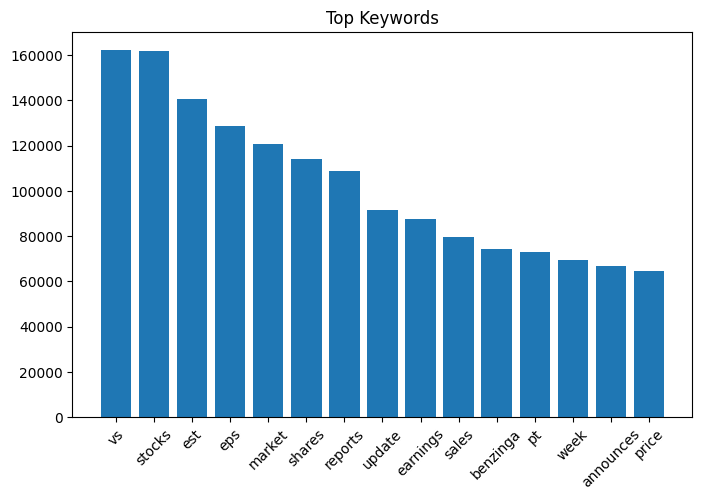

In [10]:
plt.figure(figsize=(8,5))
plt.bar(keyword_df["word"], keyword_df["count"])
plt.xticks(rotation=45)
plt.title("Top Keywords")
plt.show()